#Упражнения: Раздел 10

In [70]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as spsig
import pandas as pd

##Упражнение 10.1
Убираем эффект заварота

In [3]:
#добавляем нужные звуки
if not os.path.exists('180960__kleeb__gunshot.wav'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/180960__kleeb__gunshot.wav
if not os.path.exists('92002__jcveliz__violin-origional.wav'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/92002__jcveliz__violin-origional.wav

--2026-05-17 16:26:50--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/180960__kleeb__gunshot.wav
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/180960__kleeb__gunshot.wav [following]
--2026-05-17 16:26:50--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/180960__kleeb__gunshot.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 379256 (370K) [audio/wav]
Saving to: ‘180960__kleeb__gunshot.wav’

180960__kleeb__guns 100%[===================>] 370.37K  --.-KB/s    in 0.006s  

2026-05-17 16:26:50 (62.7 MB/s) - ‘180960__kleeb__gunshot.w

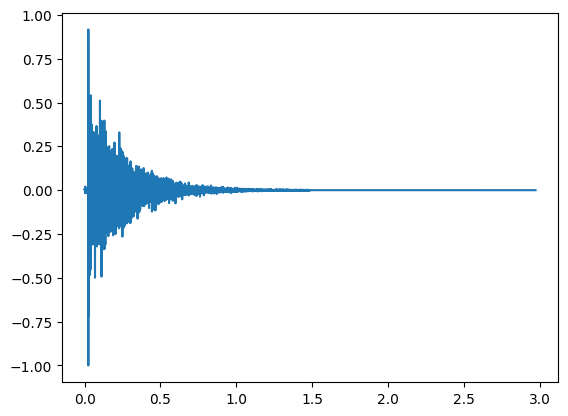

In [8]:
response = tdsp.read_wave('180960__kleeb__gunshot.wav')
#выбираем нужный фрагмент
start = 0.12
response = response.segment(start=start)
response.shift(-start)
#добавляем нулей, увеличивая длительность в 2 раза
response.truncate(2**16)
response.zero_pad(2**17)

response.normalize()
response.plot()

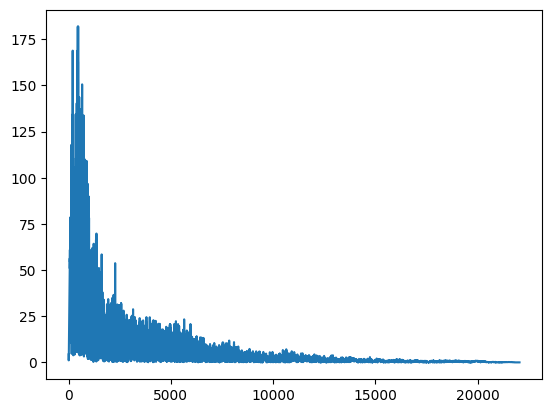

In [9]:
#спектр выстрела
transfer = response.make_spectrum()
transfer.plot()

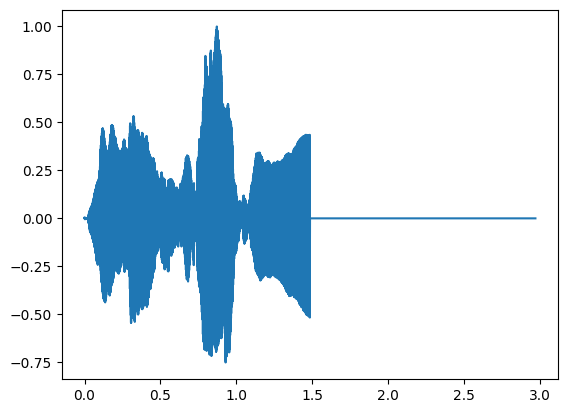

In [12]:
#ту же операцию осуществляем с звуком скрипки
violin = tdsp.read_wave('92002__jcveliz__violin-origional.wav')

start = 0.11
violin = violin.segment(start=start)
violin.shift(-start)

violin.truncate(2**16)
violin.zero_pad(2**17)

violin.normalize()
violin.plot()

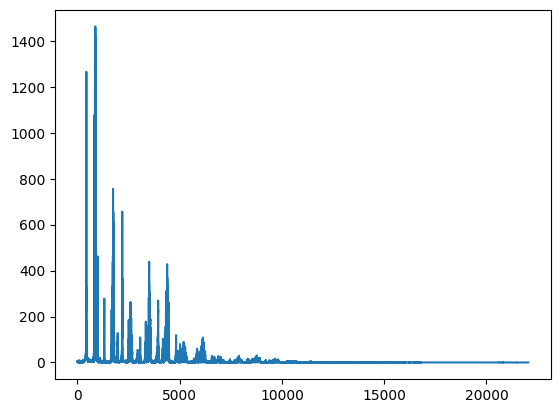

In [13]:
#спектр скрипки
spectrum = violin.make_spectrum()
spectrum.plot()

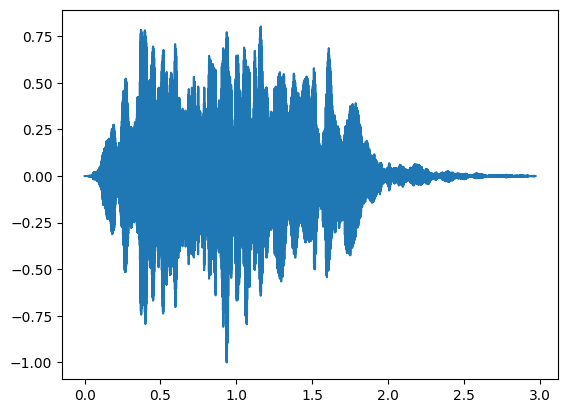

In [16]:
#перемножаем спектры
output = (spectrum * transfer).make_wave()
output.normalize()
output.plot()
output.make_audio()

Лишние ноты из начала ушли.

##Упражнение 10.2
Работа с новой импульсной характеристикой.
Для работы была выбрана характеристика: https://www.openair.hosted.york.ac.uk/?page_id=626

In [94]:
#добавляем импульсную характеристику
if not os.path.exists('r1_omni.wav'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/r1_omni.wav

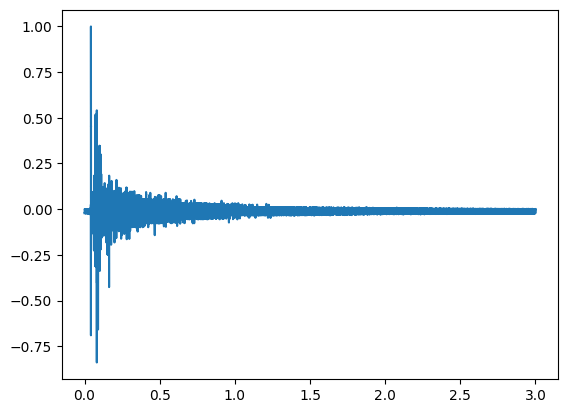

In [95]:
response = tdsp.read_wave('r1_omni.wav')
#выбираем нужный фрагмент
start = 0
response = response.segment(start=start, duration=3)
response.shift(-start)
# response.resample(framerate=44100)

response.plot()
response.make_audio()

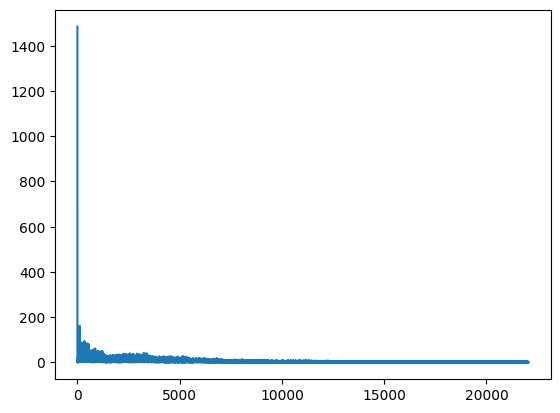

In [96]:
#передаточная функция
transfer = response.make_spectrum()
transfer.plot()

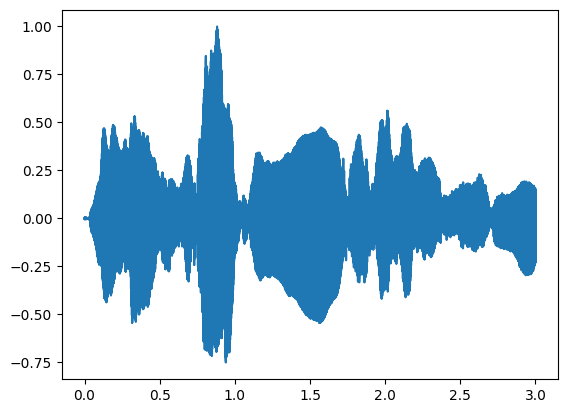

In [97]:
#подготавливаем сегмент скрипки
violin = tdsp.read_wave('92002__jcveliz__violin-origional.wav')

start = 0.1
wave = violin.segment(start=start)
wave.shift(-start)

wave.truncate(len(response))
wave.normalize()
wave.plot()
wave.make_audio()

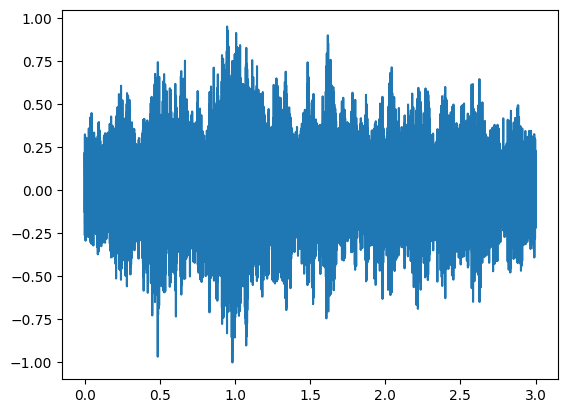

In [101]:
#получим результат через перемножение спектров
spectrum = wave.make_spectrum()
output = (spectrum * transfer).make_wave()
output.normalize()
output.plot()
output.make_audio()

Опять же получаем эффект заварота, исправим его

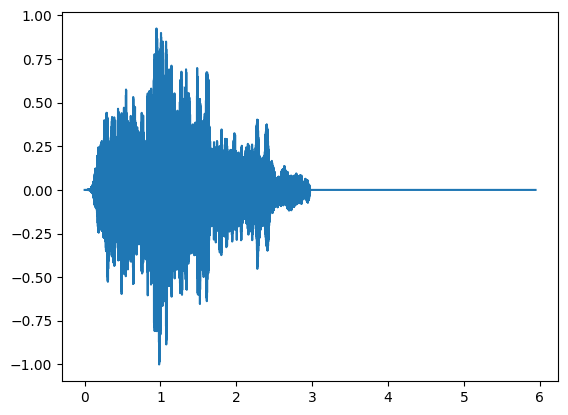

In [106]:
response.truncate(2**17)
response.zero_pad(2**18)
response.normalize()
transfer = response.make_spectrum()

wave.truncate(2**17)
wave.zero_pad(2**18)
wave.normalize()
spectrum = wave.make_spectrum()
output2 = (spectrum * transfer).make_wave()
output2.normalize()
output2.plot()
output2.make_audio()

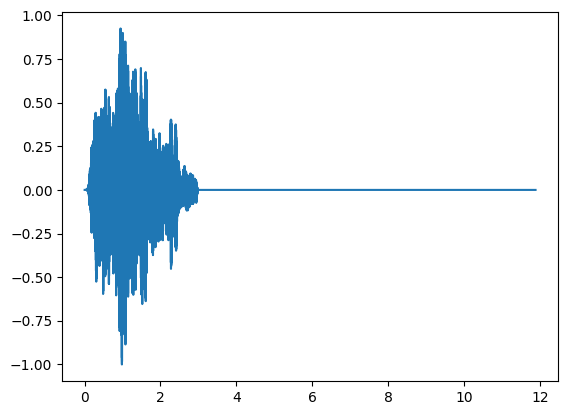

In [107]:
#осуществим те же операции через свертку
convolved2 = wave.convolve(response)
convolved2.normalize()
convolved2.plot()
convolved2.make_audio()

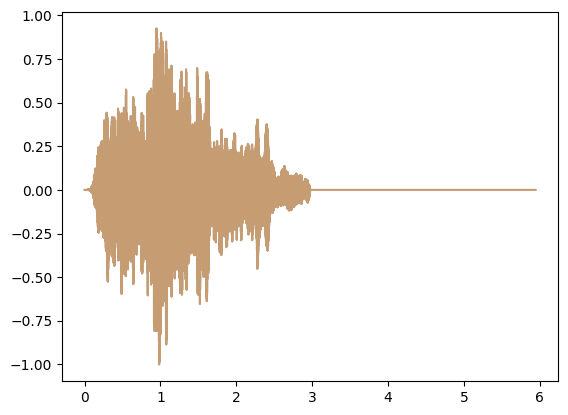

In [112]:
# наложим графики друг на друга
convolved2.segment(duration=output2.duration).plot(alpha=0.5)
output2.plot(alpha=0.5)


Можем увидеть, что графики идентичны.